# CVD prediction using machine learning

This notebook consists study of machine learning model on cardiovascular disease prediction.

Notebook follows this structure:

 Data collection

 EDA(exploratory Data analysis)

 Data Pre-processing

 Data split Train-test

 Cross Validation

 Train-test-CV comparison

 Model Development
  -Logistic regression
-Decision Tree
-KNN
-Random Forest
-Gradient boosting

-Ensemble

-Model finalising

Dataset used:
https://data.mendeley.com/datasets/dzz48mvjht/1



## Data Collection

We load the required libraries(Pandas) and load the dataset to analyze.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Cardiovascular_Disease_Dataset.csv')
df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


## Exploratory Data Analysis

we understand the dataset for any null values, duplicates, etc. this section also helps in assigning values for min,max during UI development.

In [4]:
df.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [5]:
#this outputs the shape of the dataframe (rows,columns)
print(df.shape)

#Thsi gives entries
print(df.info())

df.describe()

#Output the null-values
df.isnull().sum()

#checks for duplicate columns
df.duplicated().sum()

(1000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB
None


np.int64(0)

## Data pre-processing

After analysing the data we seprated the target variable from othe fratures. Additionally, patient_id was removed from the remaining features. Patientid and target variable are separated from base features. Patient id doesn't contribute to results prediction. This cell also shows the distribution of positive and negative case.

In [6]:
X = df.drop(['target','patientid'], axis =1)
y = df['target']

X.head()

y.head()

print(y.value_counts())

target
1    580
0    420
Name: count, dtype: int64


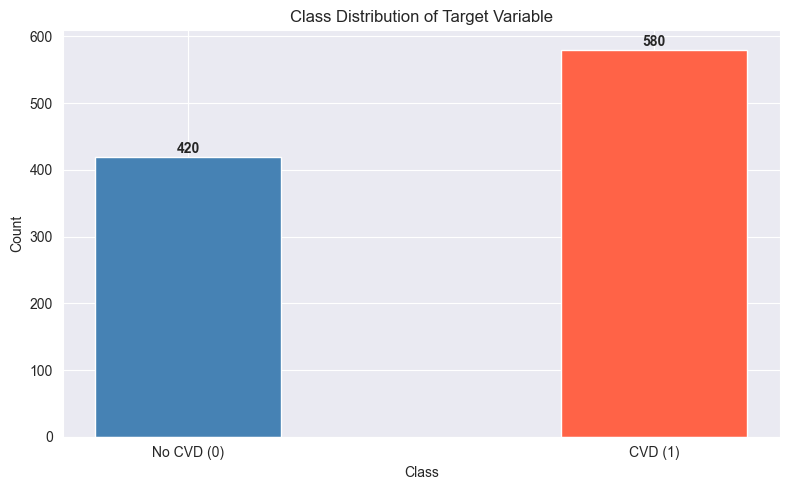

In [7]:
import matplotlib.pyplot as plt

# Your class counts
classes = ['No CVD (0)', 'CVD (1)']
counts = [420, 580]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['steelblue', 'tomato'], width=0.4)
plt.title('Class Distribution of Target Variable')
plt.xlabel('Class')
plt.ylabel('Count')

# Add count labels on top of bars
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

### Data split train-test

We split the data in train and test set before applying and model as it could lead to data leaks. Data is split in 700 test and 300 test examples.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state=45, stratify=y)

In [9]:
print("Original distribution:")
print(y.value_counts(normalize=True))

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Original distribution:
target
1    0.58
0    0.42
Name: proportion, dtype: float64

Train distribution:
target
1    0.58
0    0.42
Name: proportion, dtype: float64

Test distribution:
target
1    0.58
0    0.42
Name: proportion, dtype: float64


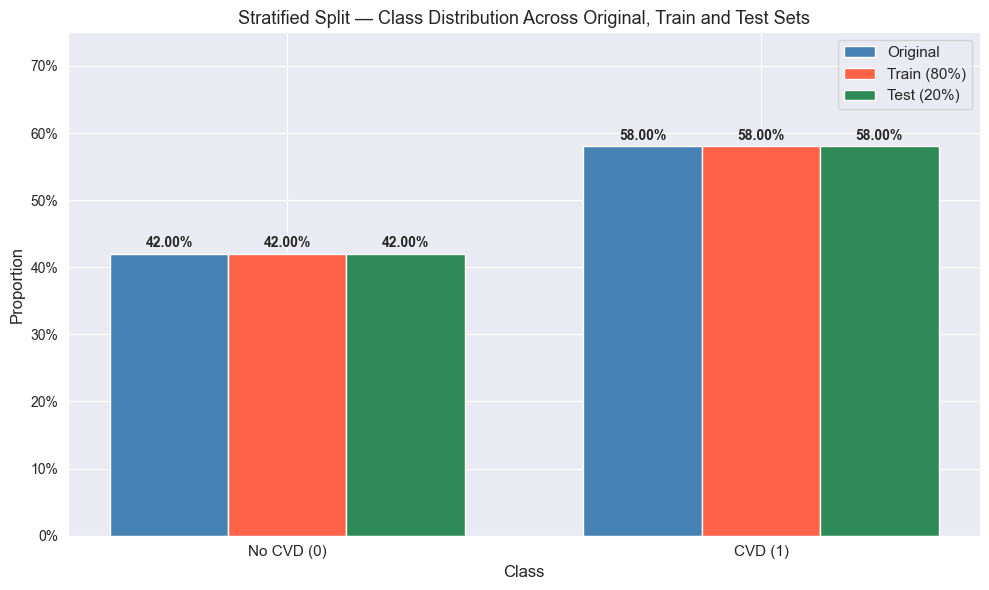

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Replace these with your actual values from the print output
original = [0.42, 0.58]  # No CVD, CVD
train = [0.42, 0.58]
test = [0.42, 0.58]

labels = ['No CVD (0)', 'CVD (1)']
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, original, width, label='Original', color='steelblue')
bars2 = ax.bar(x, train, width, label='Train (80%)', color='tomato')
bars3 = ax.bar(x + width, test, width, label='Test (20%)', color='seagreen')

# Add percentage labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Stratified Split — Class Distribution Across Original, Train and Test Sets', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.75)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('stratified_split_distribution.png', dpi=150)
plt.show()

### Heatmap

This is a heatmap depicting the relation of features with the target. Features closer to 1 have stronger relationship with target and influences more.

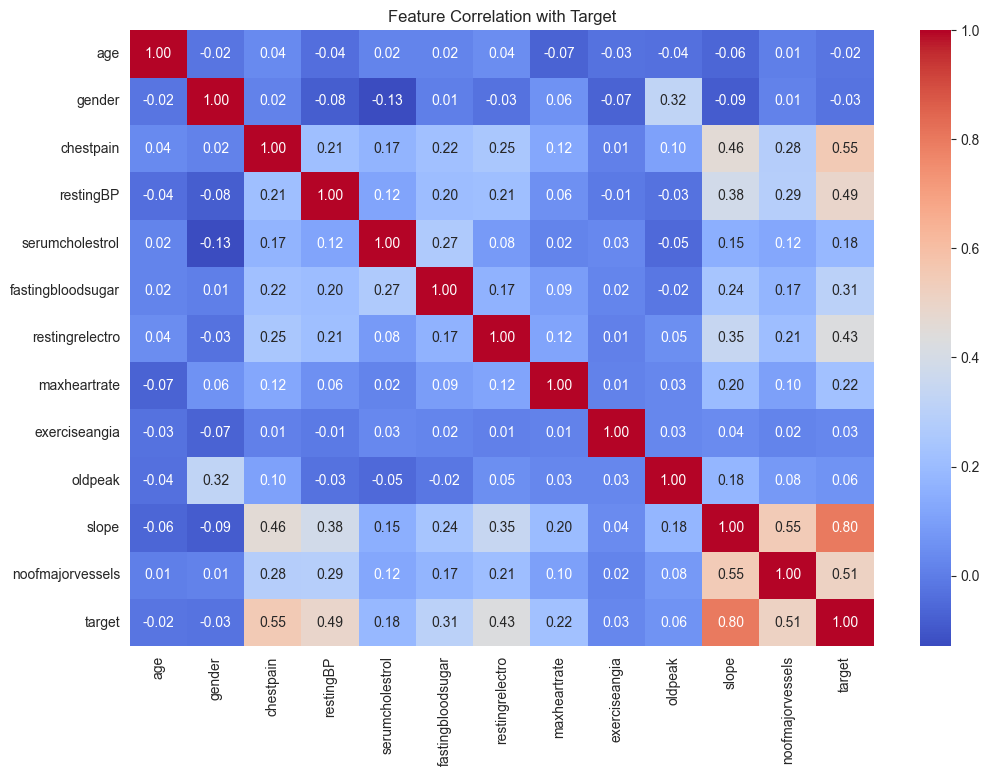

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
corr = X_train.join(y_train).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Target')
plt.show()

## Cross validation

These are the cross validation scores for all the models. 5 k-folds are taken meaning dataset is divided in 5 parts, proceeded to train-test. The average accuracy is the output. Cross validation helps in comparsion with actual test prediction if there were in close to Cv scores and not just a random result.

In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    # scale for models that are distance based
    if name in ["Logistic Regression", "KNN"]:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipeline = model  # Tree-based models no standdars scaler
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    print(name)
    print("Cross-validation scores:", scores)
    print("Average accuracy:",round(scores.mean(),4))
    print()

Logistic Regression
Cross-validation scores: [0.97857143 0.98571429 0.97857143 0.95       0.96428571]
Average accuracy: 0.9714

Decision Tree
Cross-validation scores: [0.97857143 0.95       0.92857143 0.91428571 0.96428571]
Average accuracy: 0.9471

KNN
Cross-validation scores: [0.96428571 0.92857143 0.96428571 0.90714286 0.92142857]
Average accuracy: 0.9371

Random Forest
Cross-validation scores: [0.98571429 0.95714286 0.98571429 0.94285714 0.98571429]
Average accuracy: 0.9714

Gradient Boosting
Cross-validation scores: [0.97857143 0.97142857 0.96428571 0.95       0.98571429]
Average accuracy: 0.97



### Train-Test-CV comparison

This graph compares the scores of training, testing and cross validation.

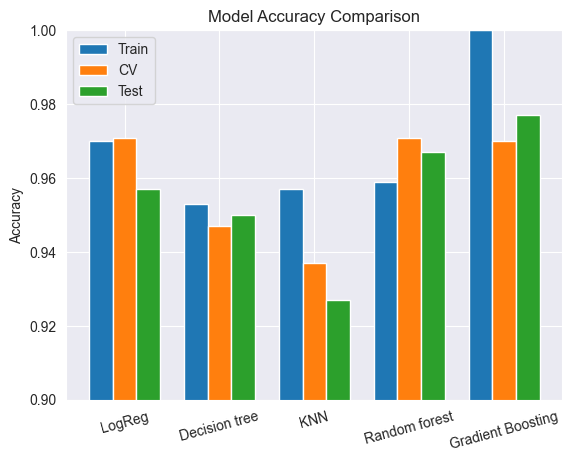

In [175]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LogReg', 'Decision tree', 'KNN', 'Random forest', 'Gradient Boosting']
train_acc = [0.970, 0.953, 0.957, 0.959, 1.00]
cv_acc = [0.971, 0.947, 0.937, 0.971, 0.97]
test_acc = [0.957, 0.950, 0.927, 0.967, 0.977]

x = np.arange(len(models))
width = 0.25

plt.bar(x - width, train_acc, width, label='Train')
plt.bar(x, cv_acc, width, label='CV')
plt.bar(x + width, test_acc, width, label='Test')

plt.xticks(x, models, rotation=15)
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.show()

## Model Development

### Logistic Regression

The following is the logic for Logistic regression model. We import the required libraries. The library includes pipeline for passing standard scaler. Standard scaler is needed in this model as logistic regression is uses values to calculate and ranges of different features have ranges which are not similar. All the features contribute equally by standard scaler.

In [187]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#logistic regression pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

#train the model
lr_pipeline.fit(X_train, y_train)

#training accuracy
train_acc = lr_pipeline.score(X_train, y_train)

test_acc = lr_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.970
Test Accuracy: 0.957


In [188]:
# comparison between actual vs predicted values
y_pred = lr_pipeline.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,1,1
4,1,1
...,...,...
295,0,0
296,0,0
297,1,1
298,1,1


#### Logistic Regression classification table and ROC score

In [189]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc


cm = confusion_matrix(y_test, y_pred)
print(cm)


print('\nClassification report \n', classification_report(y_test, y_pred))

#ROC curve score
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print('ROC AUC:', roc_auc)

[[120   6]
 [  7 167]]

Classification report 
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       126
           1       0.97      0.96      0.96       174

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

ROC AUC: 0.9916073709177158


In [138]:
from sklearn.metrics import roc_curve, auc

y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

roc_auc

0.9916073709177158

### Decision Tree Model

Decision tree model uses if/else logic forming leaf nodes from root node. It splits the data in multiple sub-sets of data and decision is at each significant step.

In [139]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state = 42,
    class_weight='balanced',
    max_depth=3,
)

#train the model
dt_model.fit(X_train, y_train)

train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.953
Test Accuracy: 0.950


In [140]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_dt

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1])

#### Decision Tree Classification report and ROC score

In [141]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt))
print('\n Classification Report:\n', classification_report(y_test, y_pred_dt))

dt_auc = roc_auc_score(y_test, y_prob_dt)
print('Decision Tree AUC score:', dt_auc)

Confusion Matrix:
 [[116  10]
 [  5 169]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       126
           1       0.94      0.97      0.96       174

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

Decision Tree AUC score: 0.9795201605546433


### K-nearest neighbours Model

k-nearest neighbours uses majority voting from results of cloast k examples. Standard scaler is required in knn as knn is distance based and higher scales influence the model more. Scaling function is applied using a pipeline to prevent data leaks.

In [142]:
from sklearn import pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train )

train_acc = knn_pipeline.score(X_train, y_train)
test_acc = knn_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.957
Test Accuracy: 0.927


#### K-nearest neighbours classification report and ROC

In [143]:
from sklearn.metrics import confusion_matrix, classification_report,  roc_auc_score


y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print('Confusion_matrix:\n', confusion_matrix(y_test, y_pred_knn))
print('\n Classification Report:\n', classification_report(y_test, y_pred_knn))

knn_auc = roc_auc_score(y_test, y_prob_knn)
print('KNN AUC score:', knn_auc)

Confusion_matrix:
 [[109  17]
 [  5 169]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.87      0.91       126
           1       0.91      0.97      0.94       174

    accuracy                           0.93       300
   macro avg       0.93      0.92      0.92       300
weighted avg       0.93      0.93      0.93       300

KNN AUC score: 0.9854953475643131


### Random Forest Model

Random forest model uses multiple trees to predict the final outcome. There is comparatively less chances of overfitting in random forest as individual trees are trained on different subset of data. Altough depth of the tree is set to 3 after experiments to reduce overfitting during training.

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 3,
    class_weight = 'balanced',
    random_state = 42,

)

rf_model.fit(X_train, y_train)

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Train Accuracy: 0.959
Test Accuracy: 0.967


#### Random Forest Classification report and ROC

In [145]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print('confusion_matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\n Classification Report:\n', classification_report(y_test, y_pred_rf))

rf_auc = roc_auc_score(y_test, y_prob_rf)
print('Random Forest AUC score:', rf_auc)

confusion_matrix:
 [[121   5]
 [  5 169]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       126
           1       0.97      0.97      0.97       174

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

Random Forest AUC score: 0.9930213464696224


### Gradient Boosting Classifier

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,


)

gb_model.fit(X_train, y_train)

train_acc = gb_model.score(X_train, y_train)
test_acc = gb_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

Train Accuracy: 1.000
Test Accuracy: 0.977


#### Gradient Boosting Classification report and ROC

In [160]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print('Confusion matrix: \n ',  confusion_matrix(y_test, y_pred_gb))
print ('\nClassification report: \n', classification_report(y_test, y_pred_gb))

gb_auc = roc_auc_score(y_test, y_prob_gb)
print('Gradient Boosting AUC score: ', gb_auc)

Confusion matrix: 
  [[120   6]
 [  1 173]]

Classification report: 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       126
           1       0.97      0.99      0.98       174

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.98       300
weighted avg       0.98      0.98      0.98       300

Gradient Boosting AUC score:  0.9966247035212553


## Comparison of model metrics

Models are compared across 4 metrics like precision, recall, f-1 score, accuracy. This shows which models perform better than others and which are more reliable.

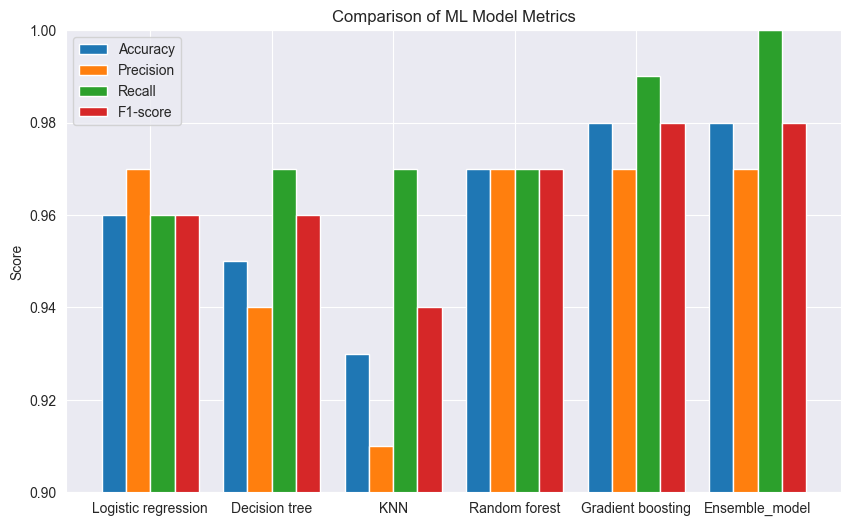

In [170]:
import numpy as np
import matplotlib.pyplot as plt
# Metrics for 5 models
models = ['Logistic regression', 'Decision tree', 'KNN', 'Random forest', 'Gradient boosting', 'Ensemble_model']
accuracy = [0.96, 0.95, 0.93, 0.97, 0.98, 0.98]
precision = [0.97, 0.94, 0.91, 0.97, 0.97, 0.97]
recall = [0.96, 0.97, 0.97, 0.97, 0.99,1.00]
f1_score = [0.96, 0.96, 0.94, 0.97, 0.98, 0.98]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1_score, width, label='F1-score')

plt.xticks(x, models)
plt.ylim(0.90,1)
plt.ylabel('Score')
plt.title('Comparison of ML Model Metrics')
plt.legend()
plt.show()

## Confusion matrix

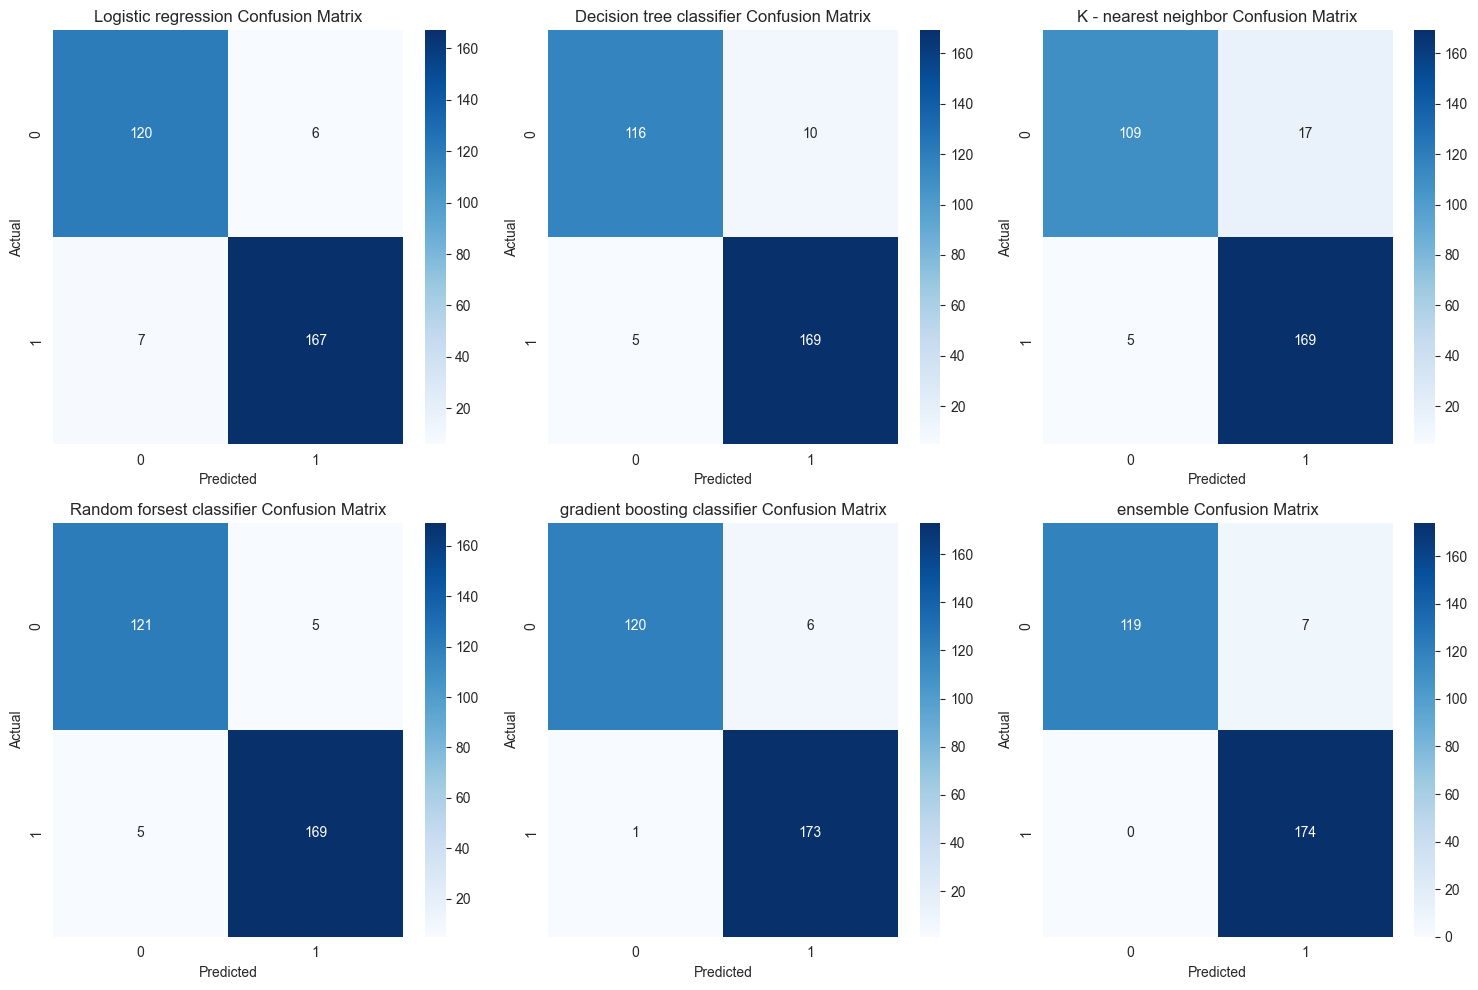

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# confision matrix with 5 models and exsemble comparison
conf_matrices = {
    'Logistic regression': np.array([[120 ,  6],
 [  7 ,167]]),
    'Decision tree classifier': np.array( [[116 , 10],
 [  5, 169]]),
    'K - nearest neighbor': np.array( [[109 , 17],
 [  5 ,169]]),
    'Random forsest classifier': np.array([[121  , 5],
 [  5, 169]]),
    'gradient boosting classifier': np.array([[120 ,  6],
 [  1,173]]),
    'ensemble': np.array([[119 ,7],[0, 174]])
}

plt.figure(figsize=(15,10))
for i, (model, cm) in enumerate(conf_matrices.items(), 1):
    plt.subplot(2,3,i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Random forest Feature importance

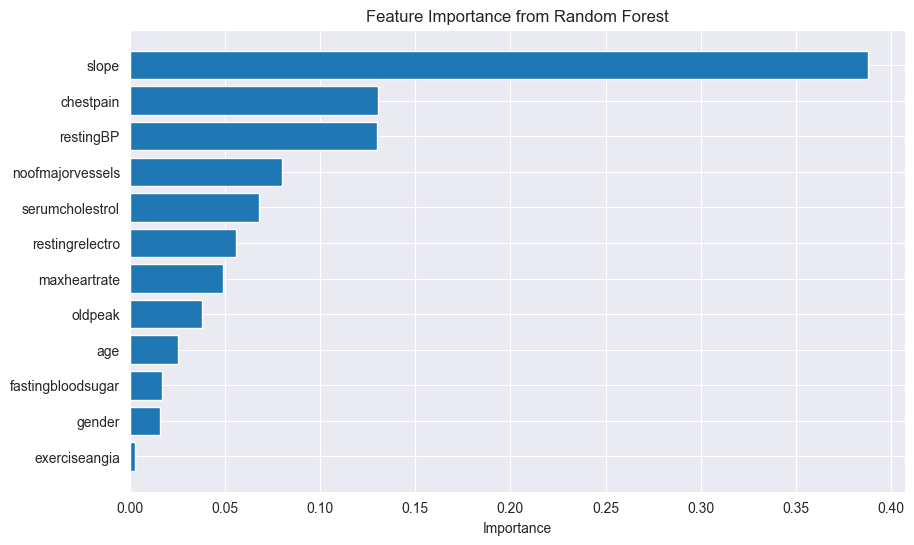

In [161]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Fit a random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()  # largest on top
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.show()

## Ensemble Model

In [162]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_pipeline),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

print("Train Accuracy:", ensemble.score(X_train, y_train))
print("Test Accuracy:", ensemble.score(X_test, y_test))



Train Accuracy: 0.9971428571428571
Test Accuracy: 0.9766666666666667


In [191]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_pipeline),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
print(y_pred)
print("Train Accuracy:", ensemble.score(X_train, y_train))
print("Test Accuracy:", ensemble.score(X_test, y_test))



[1 1 0 1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1
 1 1 1 1 0 0 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1
 0 0 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 1 1 1
 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 0
 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1 0 1 1 0
 1 1 1 1 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0 0 1 1 0 0 0 1 1 1 0 0 1 0
 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 1 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0
 0 1 1 1]
Train Accuracy: 0.9971428571428571
Test Accuracy: 0.9766666666666667


#### Ensemble model classification report and ROC

In [163]:
y_prob = ensemble.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[119   7]
 [  0 174]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       126
           1       0.96      1.00      0.98       174

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.98       300
weighted avg       0.98      0.98      0.98       300



### ROC and AUC scores

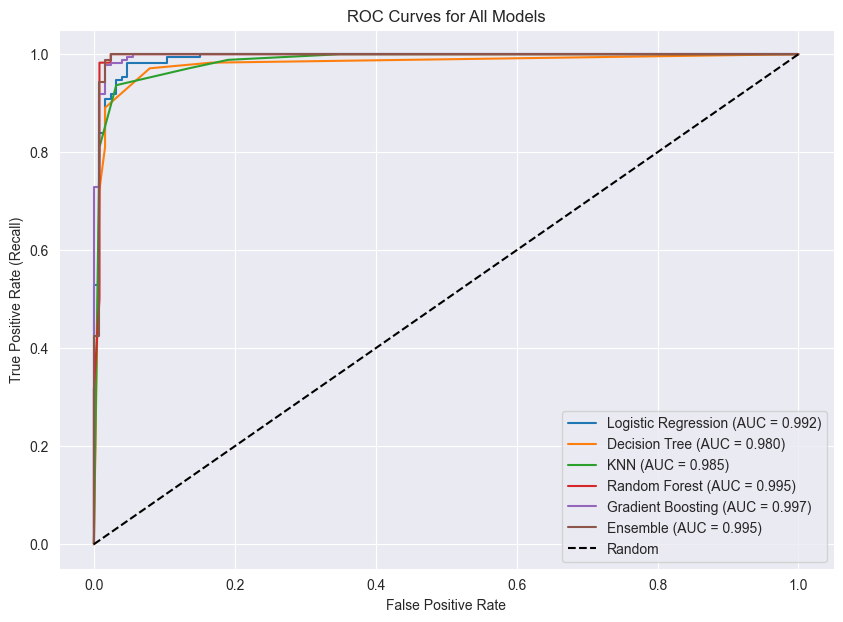

In [180]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Models
models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree': dt_model,
    'KNN': knn_pipeline,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'Ensemble': ensemble
}

plt.figure(figsize=(10, 7))

# Loop through models and calculate ROC and AUC
for name, model in models.items():
    # Predict probabilities for positive class
    y_probs = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)

    # Compute AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Plot formatting
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.show()

## Pickle ensemble Model save

In [155]:
import pickle

# Save the ensemble model to a file
with open('final_ensemble_model.pkl', 'wb') as file:
    pickle.dump(ensemble, file)

print("Model saved as final_ensemble_model.pkl")

Model saved as final_ensemble_model.pkl


In [19]:
# Load the model from the file
with open('final_ensemble_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)



Shap

In [20]:

pickle.dump(gb_model, open('gb_model.pkl', 'wb'))
print("Model saved as gb_model.pkl")

Model saved as gb_model.pkl
